In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

In [3]:
housing = fetch_california_housing()

In [4]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)

In [5]:
target = pd.Series(data=housing.target, name=housing.target_names[0])

In [6]:
df[housing.target_names[0]] = target

In [7]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
df.shape

(20640, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: >

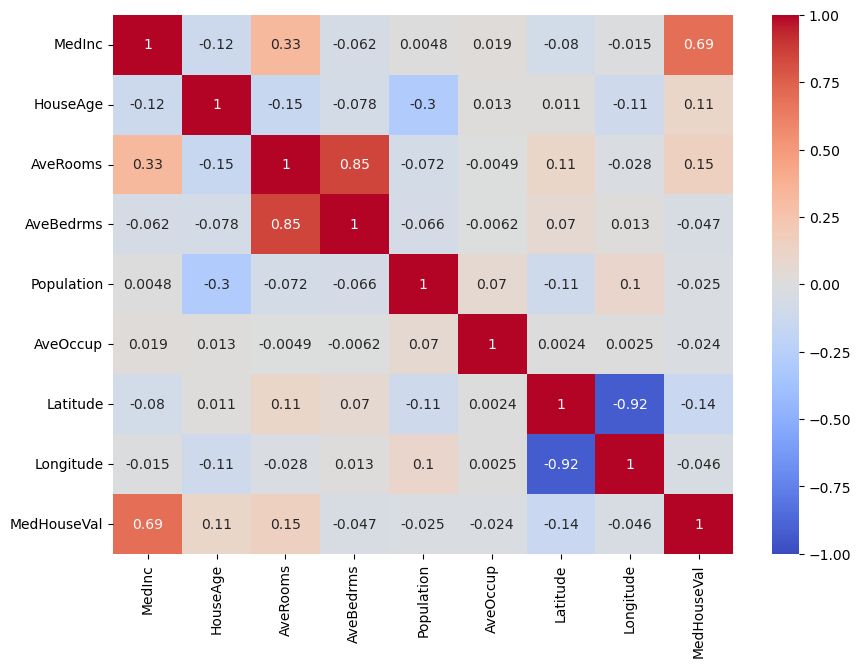

In [11]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(),
           cmap='coolwarm',
           vmin=-1,
           vmax=1,
           annot=True)

## Simple Linear Regression

In this section, we will perform simple linear regression, using only the MedInc as the independant variable, and the MedHouseVal as the dependant variable. 

In [12]:
X = df[['MedInc']]

In [13]:
y = target

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=312)

In [15]:
lr = LinearRegression()

In [16]:
lr.fit(X_train, y_train)

LinearRegression()

In [17]:
lr.score(X_train, y_train)

0.4751204332149066

In [18]:
lr.score(X_test, y_test)

0.46863236243895345

With simple linear regression using only the median income as the independant variable, we are able to explain around 46% of the variability of the target variable, the house value

In [19]:
train_predictions = lr.predict(X_train)
test_predictions = lr.predict(X_test)

In [20]:
root_mean_squared_error(y_train, train_predictions)

0.8310958307996925

In [21]:
root_mean_squared_error(y_test, test_predictions)

0.8558009212701501

In [22]:
mean_test = y_test.mean()

In [23]:
baseline_preds = np.full_like(y_test, mean_test)

In [24]:
root_mean_squared_error(y_test, baseline_preds)

1.1740191997760434

In [25]:
# We beat the baseline 

In [26]:
lr.coef_

array([0.41788564])

In the above cells, we calculated the root mean square error (RMSE) for the training data, testing data, and the baseline. The baseline predictions predict the mean price for every house in the test data. 

Our RMSE for the training data is 0.83. This is in the same units as the target variable, which is hundreds of thousands of dollars, so this means that, on average, the predictions of the training data was off by ~$83,000. 

For the testing data, the RMSE was 0.86, so it was off by approximately $86,000 on average. 

For the baseline, it was off by 1.17, or $117,000 on average. 

Our model performs better than the baseline, but it is still off by a substantial amount. Let's see what happens if we include more features. 

## Multiple Linear Regression

Now we will use multiple columns

In [27]:
X = df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms']]

In [28]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=312)

In [30]:
lr_multiple = LinearRegression()

In [31]:
lr_multiple.fit(X_train, y_train)

LinearRegression()

In [32]:
lr_multiple.score(X_train, y_train)

0.535411230824401

In [33]:
lr_multiple.score(X_test, y_test)

0.5428567568261201

In [34]:
train_predictions = lr_multiple.predict(X_train)
test_predictions = lr_multiple.predict(X_test)

In [35]:
root_mean_squared_error(y_train, train_predictions)

0.7819079414569048

In [36]:
root_mean_squared_error(y_test, test_predictions)

0.7937821926105942

In [37]:
mean_test = y_test.mean()
baseline_preds = np.full_like(y_test, mean_test)

In [38]:
root_mean_squared_error(y_test, baseline_preds)

1.1740191997760434

In [39]:
# We beat baseline.

Loosk like our multiple linear regression performed slightly better than the simple linear regression.

On average, the predicted prices on the training set was off by around \$78,000 (which is an improvement from the \$83,000 from simple linear regression), and the predicted prices for the testing set was off by around \$79,000, which is an improvement from the \$86,000 from simple linear regression. 

In [41]:
housing.DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S